# DNA Classification: Exploratory Data Analysis

## Project objective

This notebook explores a synthetic dataset of 3,000 DNA samples and establishes
what a classifier can and cannot be expected to learn from it. The prediction
target is `Class_Label` (`Bacteria`, `Human`, `Plant`, or `Virus`).

Column roles used throughout the project:

| Column | Role |
| --- | --- |
| `Sample_ID` | Identifier, never a predictor |
| `Sequence` | Biological input, source of the engineered features |
| `GC_Content`, `AT_Content`, `Num_A`, `Num_T`, `Num_C`, `Num_G`, `Sequence_Length`, `kmer_3_freq` | Supplied summaries of the sequence |
| `Mutation_Flag`, `Disease_Risk` | Categorical descriptors, label-encoded for the model |
| `Class_Label` | Categorical target, label-encoded for the model |

## How this notebook is organized

| Part | Question it answers |
| --- | --- |
| 1. Data integrity | Is the file clean and internally consistent? |
| 2. Target and descriptors | How are the classes and categorical columns distributed? |
| 3. Is this DNA random? | Do the sequences show any structure a real genome would have? |
| 4. K-mer landscape | Do any short motifs distinguish the classes? |
| 5. Structure in sequence space | Do same-class sequences resemble each other at all? |
| 6. The dataset's own questions | What do the documented research questions actually answer to? |
| 7. Effect sizes and conclusions | How large is any real effect, and what does that imply for modeling? |

Every analysis note appears directly **below** the output it describes. The
dataset is synthetic and intended for education; it does not represent real
patient or genomic data.

In [9]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "input").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "input").exists():
    raise FileNotFoundError("Could not locate the project input directory.")

DATA_PATH = PROJECT_ROOT / "input" / "synthetic_dna_dataset.csv"
OUTPUT_PATH = PROJECT_ROOT / "reports" / "figures"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

DNA_BASES = ("A", "C", "G", "T")
# Palette checked for colorblind separation before use: gray is the neutral
# reference, blue the highlighted series, orange the expectation marker.
NEUTRAL, HIGHLIGHT, REFERENCE = "#b3b3b3", "#386cb0", "#d95f02"
RANDOM_STATE = 42

# Part 1 — Data integrity

## Load the data

In [10]:
data = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {data.shape[0]:,} rows by {data.shape[1]} columns")
display(data.head())

Dataset shape: 3,000 rows by 13 columns


,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.000,50.000,100,22,28,19,31,0.986,0,Bacteria,High
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.000,55.000,100,27,28,22,23,0.486,1,Virus,Medium
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.000,49.000,100,26,23,30,21,0.367,1,Bacteria,Low
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.000,45.000,100,28,17,23,32,0.404,0,Human,Medium
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.000,54.000,100,24,30,25,21,0.818,0,Human,High


**Analysis.** The file loads with 3,000 rows and 13 columns, matching the data
dictionary. Each row carries one raw DNA string plus nine numeric summaries of
that string, two categorical descriptors, and the class label. Because the
numeric summaries are recomputable from `Sequence`, the sequence itself is the
only genuinely independent piece of information in each row.

## Structure and data quality

In [11]:
data.info()
display(data.isna().sum().rename("missing_values").to_frame())
print(f"Duplicate rows: {data.duplicated().sum():,}")
print(f"Unique sample IDs: {data['Sample_ID'].nunique():,}")
print(f"Duplicate sequences: {data['Sequence'].duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   object 
 1   Sequence         3000 non-null   object 
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   object 
 12  Disease_Risk     3000 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 304.8+ KB


,missing_values
Sample_ID,0
Sequence,0
GC_Content,0
AT_Content,0
Sequence_Length,0
Num_A,0
Num_T,0
Num_C,0
Num_G,0
kmer_3_freq,0


Duplicate rows: 0
Unique sample IDs: 3,000
Duplicate sequences: 0


**Analysis.** Data quality is clean: no missing values in any column, no
duplicated rows, 3,000 distinct `Sample_ID` values, and no repeated DNA string.
Dtypes are already correct, so `Sequence`, `Class_Label`, and `Disease_Risk`
arrive as text objects while the counts and content percentages arrive as
numbers. No imputation or de-duplication step is needed before modeling.

## Sequence length, alphabet, and internal consistency

In [12]:
data["Observed_Sequence_Length"] = data["Sequence"].str.len()
sequence_lengths = data["Observed_Sequence_Length"].value_counts().sort_index()
observed_alphabet = sorted(set("".join(data["Sequence"].astype(str))))
length_matches = bool(
    (data["Observed_Sequence_Length"] == data["Sequence_Length"]).all()
)
base_totals = data[["Num_A", "Num_T", "Num_C", "Num_G"]].sum(axis=1)
content_totals = data["GC_Content"] + data["AT_Content"]
gc_matches_counts = np.allclose(
    data["GC_Content"],
    100 * (data["Num_G"] + data["Num_C"]) / data["Sequence_Length"],
)

print("Sequence lengths:")
display(sequence_lengths.rename("sample_count").to_frame())
print("Observed sequence alphabet:", observed_alphabet)
print(f"Observed length equals Sequence_Length for every row: {length_matches}")
print(f"Num_A + Num_T + Num_C + Num_G unique totals: {sorted(base_totals.unique())}")
print(f"GC_Content + AT_Content unique totals: {sorted(content_totals.unique())}")
print(f"GC_Content is exactly recomputable from the base counts: {gc_matches_counts}")

Sequence lengths:


,sample_count
Observed_Sequence_Length,
100,3000


Observed sequence alphabet: ['A', 'C', 'G', 'T']
Observed length equals Sequence_Length for every row: True
Num_A + Num_T + Num_C + Num_G unique totals: [100]
GC_Content + AT_Content unique totals: [100.0]
GC_Content is exactly recomputable from the base counts: True


**Analysis.** Every sequence is exactly 100 bases long, so sequence length
carries no information and cannot separate the classes. The alphabet is limited
to the four canonical bases A, C, G, and T, which means feature extraction never
has to handle ambiguity codes such as `N`.

The consistency checks confirm the supplied summaries are exact rather than
approximate: base counts always total 100, `GC_Content + AT_Content` always
totals 100, and `GC_Content` is reproducible from `Num_G + Num_C` to floating
point precision. Those columns are therefore **deterministic functions of
`Sequence`**, not independent measurements. This is why the model rebuilds its
numeric features from the sequence itself instead of consuming them — feeding
both would add collinearity without adding information.

# Part 2 — Target and descriptors

## Class balance

,sample_count,percent_of_rows
Class_Label,,
Bacteria,761,25.370
Human,749,24.970
Plant,747,24.900
Virus,743,24.770


Chi-square test for equal class sizes: chi2=0.240 p=0.9709
Random-chance accuracy for 4 balanced classes: 0.250


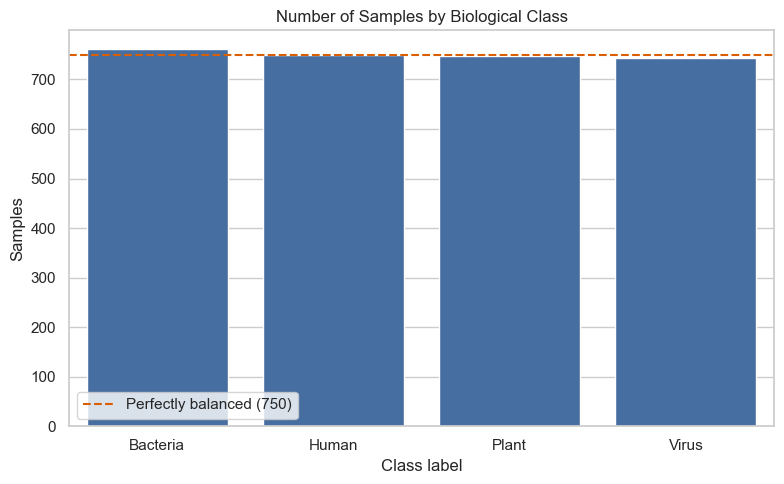

In [13]:
class_counts = data["Class_Label"].value_counts().sort_values(ascending=False)
class_share = (class_counts / len(data) * 100).round(2)
display(pd.DataFrame({"sample_count": class_counts, "percent_of_rows": class_share}))

chi2_balance, p_balance = stats.chisquare(class_counts.to_numpy())
print(
    f"Chi-square test for equal class sizes: chi2={chi2_balance:.3f} "
    f"p={p_balance:.4f}"
)
print(f"Random-chance accuracy for {len(class_counts)} balanced classes: "
      f"{1 / len(class_counts):.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=data, x="Class_Label", order=class_counts.index, ax=ax, color=HIGHLIGHT
)
ax.axhline(
    len(data) / len(class_counts),
    color=REFERENCE,
    linestyle="--",
    label="Perfectly balanced (750)",
)
ax.set(
    title="Number of Samples by Biological Class",
    xlabel="Class label",
    ylabel="Samples",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** The four classes are almost perfectly balanced — Bacteria 761,
Human 749, Plant 747, Virus 743 — and a chi-square test cannot reject equal
class sizes. Two consequences follow. First, plain accuracy is a fair headline
metric here, since no class can be inflated by majority guessing. Second, **the
baseline to beat is 25%**: any model scoring near that level has learned
nothing. This number is the reference point for every result in the modeling
notebooks. The train/test split is still stratified so the proportions hold in
both partitions.

## Sequence composition by class

GC_Content       AT_Content        Num_A        Num_T        \
                  mean   std       mean   std   mean   std   mean   std   
Class_Label                                                               
Bacteria        50.143 4.975     49.857 4.975 25.062 4.240 24.795 4.334   
Human           50.661 5.084     49.339 5.084 24.591 4.266 24.748 4.393   
Plant           49.918 5.102     50.082 5.102 25.086 4.347 24.996 4.254   
Virus           49.754 5.054     50.246 5.054 25.063 4.406 25.183 4.282   

             Num_C        Num_G        
              mean   std   mean   std  
Class_Label                            
Bacteria    25.070 4.205 25.074 4.312  
Human       25.028 4.284 25.633 4.351  
Plant       24.956 4.514 24.963 4.321  
Virus       24.961 4.399 24.793 4.297

,max_minus_min_class_mean,pooled_std,ratio
GC_Content,0.907,5.063,0.179
AT_Content,0.907,5.063,0.179
Num_A,0.494,4.317,0.115
Num_T,0.435,4.318,0.101
Num_C,0.114,4.349,0.026
Num_G,0.840,4.330,0.194


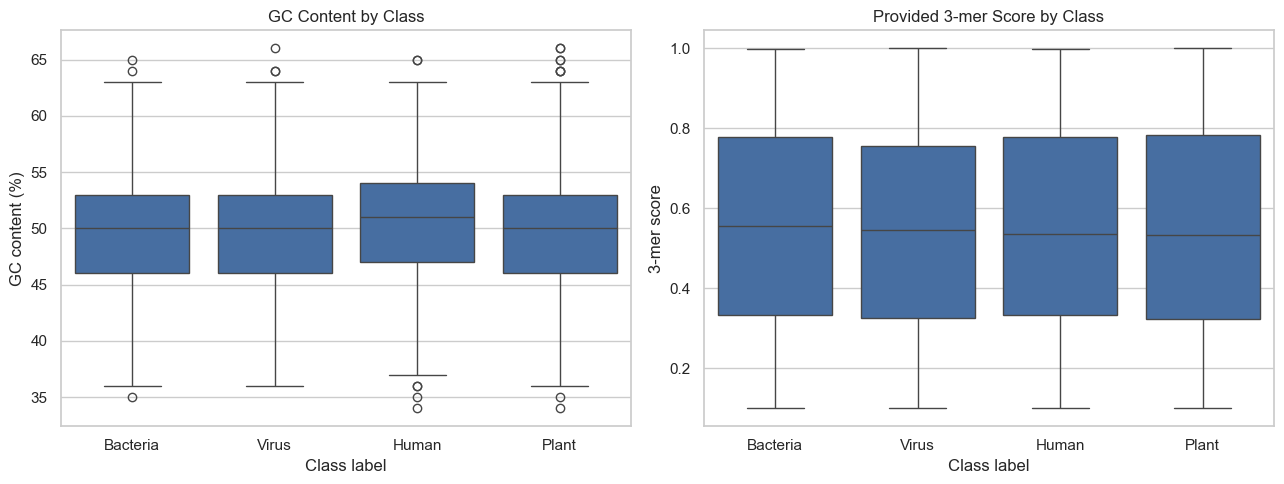

In [14]:
composition_columns = ["GC_Content", "AT_Content", "Num_A", "Num_T", "Num_C", "Num_G"]
composition_summary = data.groupby("Class_Label")[composition_columns].agg(
    ["mean", "std"]
)
display(composition_summary.round(3))

spread = (
    data.groupby("Class_Label")[composition_columns].mean().max()
    - data.groupby("Class_Label")[composition_columns].mean().min()
)
pooled = data[composition_columns].std()
display(
    pd.DataFrame(
        {
            "max_minus_min_class_mean": spread,
            "pooled_std": pooled,
            "ratio": spread / pooled,
        }
    ).round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=data, x="Class_Label", y="GC_Content", ax=axes[0], color=HIGHLIGHT)
axes[0].set(title="GC Content by Class", xlabel="Class label", ylabel="GC content (%)")
sns.boxplot(data=data, x="Class_Label", y="kmer_3_freq", ax=axes[1], color=HIGHLIGHT)
axes[1].set(
    title="Provided 3-mer Score by Class",
    xlabel="Class label",
    ylabel="3-mer score",
)
fig.tight_layout()
fig.savefig(
    OUTPUT_PATH / "sequence_features_by_class.png", dpi=160, bbox_inches="tight"
)
plt.show()

**Analysis.** Composition is nearly identical across the four classes. Mean GC
content sits between 49.8% and 50.7% for every class with a standard deviation of
about 5 percentage points, so the class-to-class spread is under one fifth of the
within-class spread — the ratio table makes that explicit. The boxplots overlap
almost completely and the supplied `kmer_3_freq` score is spread uniformly with
no class-specific shift.

This is the first substantive warning sign. In real genomic data GC content
differs markedly between bacteria, viruses, plants, and humans, and it is one of
the classic discriminating features in sequence classification. Here it does not
discriminate at all, which suggests the sequences were not generated per class.

## Categorical descriptors

Mutation_Flag values: [0, 1]
Disease_Risk values: ['High', 'Low', 'Medium']

Mutation_Flag share within each class:


Mutation_Flag,0,1
Class_Label,,
Bacteria,0.494,0.506
Human,0.486,0.514
Plant,0.535,0.465
Virus,0.498,0.502


Disease_Risk share within each class:


Disease_Risk,High,Low,Medium
Class_Label,,,
Bacteria,0.351,0.302,0.347
Human,0.336,0.327,0.336
Plant,0.368,0.321,0.311
Virus,0.339,0.354,0.307


Association with Class_Label:


,descriptor,cramers_v,p_value
0,Mutation_Flag,0.038,0.228
1,Disease_Risk,0.035,0.308


Cramer's V benchmarks: 0.1 = weak, 0.3 = moderate, 0.5 = strong


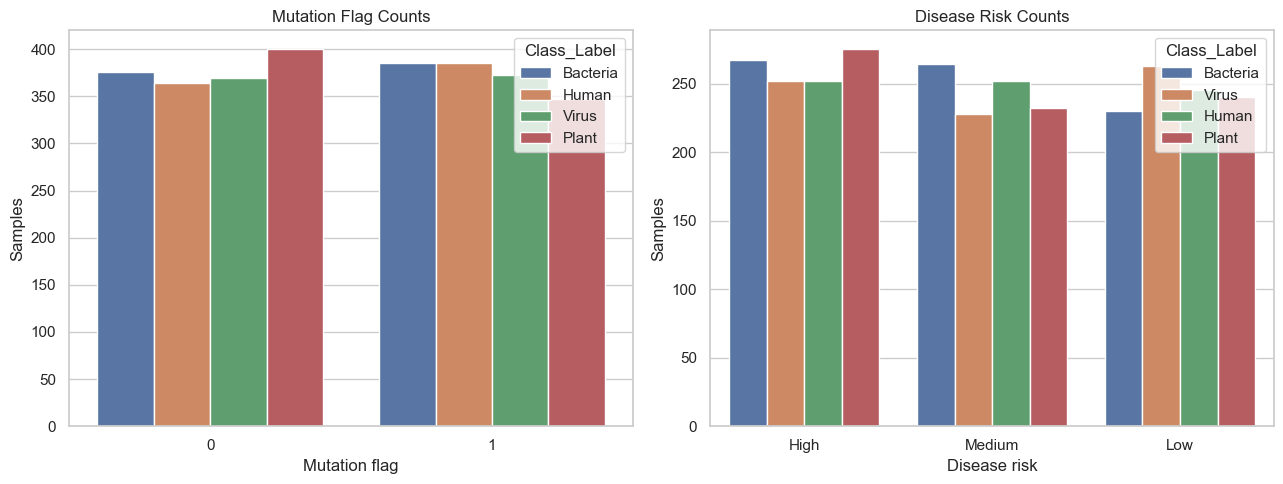

In [15]:
print("Mutation_Flag values:", sorted(data["Mutation_Flag"].unique()))
print("Disease_Risk values:", sorted(data["Disease_Risk"].unique()))

mutation_by_class = pd.crosstab(
    data["Class_Label"], data["Mutation_Flag"], normalize="index"
)
risk_by_class = pd.crosstab(data["Class_Label"], data["Disease_Risk"], normalize="index")
print("\nMutation_Flag share within each class:")
display(mutation_by_class.round(3))
print("Disease_Risk share within each class:")
display(risk_by_class.round(3))


def cramers_v(table: pd.DataFrame) -> tuple[float, float]:
    """Return Cramer's V and the chi-square p-value for a contingency table."""
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1)))), float(p_value)


association_rows = []
for column in ["Mutation_Flag", "Disease_Risk"]:
    v, p_value = cramers_v(pd.crosstab(data["Class_Label"], data[column]))
    association_rows.append(
        {"descriptor": column, "cramers_v": v, "p_value": p_value}
    )
print("Association with Class_Label:")
display(pd.DataFrame(association_rows).round(4))
print("Cramer's V benchmarks: 0.1 = weak, 0.3 = moderate, 0.5 = strong")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=data, x="Mutation_Flag", hue="Class_Label", ax=axes[0])
axes[0].set(title="Mutation Flag Counts", xlabel="Mutation flag", ylabel="Samples")
sns.countplot(data=data, x="Disease_Risk", hue="Class_Label", ax=axes[1])
axes[1].set(title="Disease Risk Counts", xlabel="Disease risk", ylabel="Samples")
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "categorical_features.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** `Mutation_Flag` is binary and splits close to 50/50 inside every
class, ranging only from 46.5% to 51.4% positive. `Disease_Risk` takes three
values and each class shows roughly a third in each band.

Cramér's V quantifies this properly: **0.038 for `Mutation_Flag` and 0.035 for
`Disease_Risk`**, against a benchmark where 0.1 already counts as a weak
association. Both are effectively zero, and neither chi-square test is
significant. Neither descriptor will help predict `Class_Label`. They are still
the dataset's two genuine categorical predictors, so they are the columns the
label-encoding step below converts for the model — the modeling notebooks
include them, and the search in notebook 04 is free to discard them.

## Feature engineering: label encoding the categorical variables

`Mutation_Flag` and `Disease_Risk` are categorical descriptors and `Class_Label`
is a categorical target. Scikit-learn estimators require numeric input, so each
is converted with `LabelEncoder`, which maps every distinct category to an
integer code.

In [16]:
encoding_preview = data.copy()
encoding_tables = {}
for column in ["Mutation_Flag", "Disease_Risk", "Class_Label"]:
    encoder = LabelEncoder().fit(encoding_preview[column].astype(str))
    encoded_name = f"{column.lower()}_encoded"
    encoding_preview[encoded_name] = encoder.transform(
        encoding_preview[column].astype(str)
    )
    encoding_tables[column] = pd.DataFrame(
        {
            "category": encoder.classes_,
            "encoded_value": range(len(encoder.classes_)),
        }
    )

for column, table in encoding_tables.items():
    print(f"{column} label encoding:")
    display(table)

display(
    encoding_preview[
        [
            "Mutation_Flag",
            "mutation_flag_encoded",
            "Disease_Risk",
            "disease_risk_encoded",
            "Class_Label",
            "class_label_encoded",
        ]
    ].head(8)
)

Mutation_Flag label encoding:


,category,encoded_value
0,0,0
1,1,1


Disease_Risk label encoding:


,category,encoded_value
0,High,0
1,Low,1
2,Medium,2


Class_Label label encoding:


,category,encoded_value
0,Bacteria,0
1,Human,1
2,Plant,2
3,Virus,3


,Mutation_Flag,mutation_flag_encoded,Disease_Risk,disease_risk_encoded,Class_Label,class_label_encoded
0,0,0,High,0,Bacteria,0
1,1,1,Medium,2,Virus,3
2,1,1,Low,1,Bacteria,0
3,0,0,Medium,2,Human,1
4,0,0,High,0,Human,1
5,1,1,Low,1,Plant,2
6,1,1,High,0,Bacteria,0
7,0,0,Low,1,Virus,3


**Analysis.** The encoder assigns codes alphabetically: `Mutation_Flag` maps
`0 -> 0` and `1 -> 1`; `Disease_Risk` maps `High -> 0`, `Low -> 1`,
`Medium -> 2`; and `Class_Label` maps `Bacteria -> 0`, `Human -> 1`,
`Plant -> 2`, `Virus -> 3`.

Two cautions follow. The codes are alphabetical, not ordinal, so the
`Disease_Risk` order `High < Low < Medium` does **not** reflect increasing
severity. Tree-based models and models that split on arbitrary thresholds handle
this safely; a linear model would read a false ordering, which is one reason the
comparison spans ten algorithm families. Second, the same encoder objects must
be reused at prediction time, so the project fits them inside the modeling
pipeline and stores them in the saved bundle.

DNA bases are deliberately **not** label-encoded. Mapping `A/C/G/T -> 0/1/2/3`
would tell a model that `T` is three times `A`, which is biologically
meaningless. Bases are instead expressed as per-position one-hot indicators,
composition frequencies, and k-mer frequencies.

## Correlation among the supplied numeric features

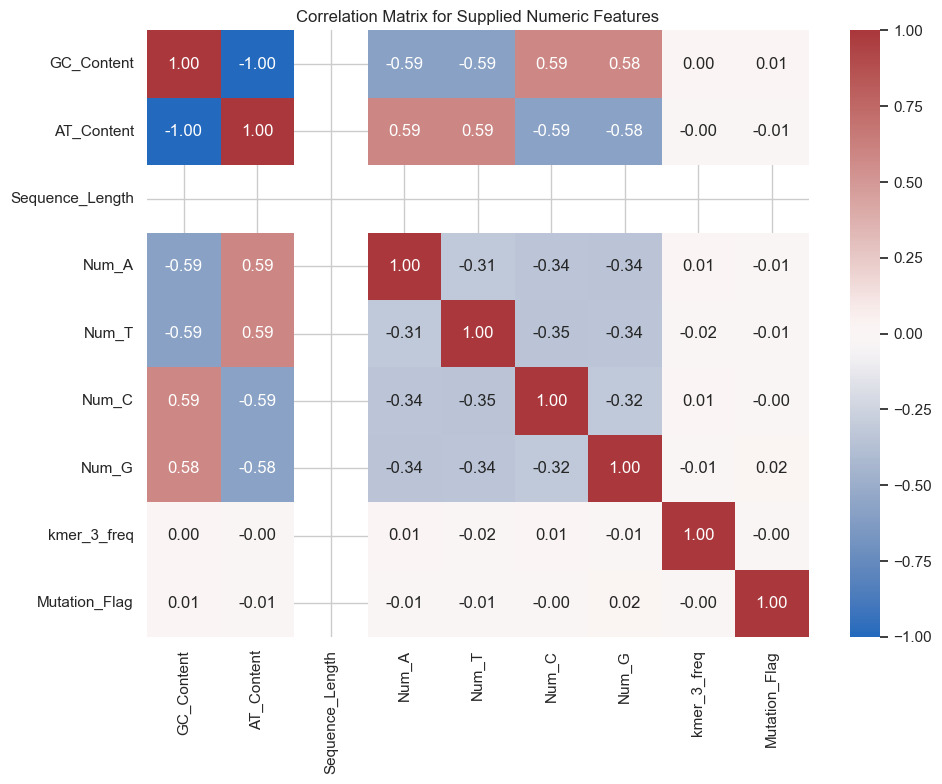

In [17]:
numeric_columns = [
    "GC_Content", "AT_Content", "Sequence_Length", "Num_A", "Num_T",
    "Num_C", "Num_G", "kmer_3_freq", "Mutation_Flag",
]
correlation = data[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix for Supplied Numeric Features")
fig.tight_layout()
fig.savefig(
    OUTPUT_PATH / "numeric_feature_correlations.png", dpi=160, bbox_inches="tight"
)
plt.show()

**Analysis.** The heatmap exposes deterministic redundancy rather than
biological structure. `GC_Content` and `AT_Content` correlate at exactly -1.00
because they sum to 100, and each is perfectly explained by the underlying base
counts. `Sequence_Length` is constant, so its correlations are undefined.
`kmer_3_freq` and `Mutation_Flag` are essentially uncorrelated with everything
else. Feeding all of these to a linear model together would create severe
collinearity — another reason the model rebuilds features from `Sequence`.

# Part 3 — Is this DNA random?

Parts 1 and 2 showed that the supplied summaries do not separate the classes.
That could mean the summaries are the wrong features, or it could mean the
sequences themselves carry no structure. This part tests the sequences directly
against what pure randomness would produce.

Real genomes are conspicuously **non**-random: they have skewed base
composition, positional structure from codons and motifs, repeated elements, and
over-represented k-mers. If none of those signatures appear, the sequences were
generated by a uniform random draw, and no feature engineering can recover
information that was never written.

## Nucleotide composition against a uniform draw

In [18]:
sequences = data["Sequence"].to_numpy()
n_sequences, sequence_length = len(sequences), len(sequences[0])
base_matrix = np.frombuffer(
    "".join(sequences).encode(), dtype="S1"
).reshape(n_sequences, sequence_length)

global_counts = {
    base: int((base_matrix == base.encode()).sum()) for base in DNA_BASES
}
total_bases = sum(global_counts.values())
chi2_bases, p_bases = stats.chisquare(list(global_counts.values()))

display(
    pd.DataFrame(
        {
            "count": global_counts,
            "observed_fraction": {
                b: c / total_bases for b, c in global_counts.items()
            },
            "expected_fraction": {b: 0.25 for b in DNA_BASES},
        }
    ).round(5)
)
print(f"Total bases: {total_bases:,}")
print(
    f"Chi-square goodness of fit vs uniform 25%: chi2={chi2_bases:.3f} "
    f"df=3 p={p_bases:.4f}"
)

,count,observed_fraction,expected_fraction
A,74852,0.250,0.250
C,75012,0.250,0.250
G,75348,0.251,0.250
T,74788,0.249,0.250


Total bases: 300,000
Chi-square goodness of fit vs uniform 25%: chi2=2.508 df=3 p=0.4739


**Analysis.** The four bases occur at 24.95%, 25.00%, 25.12%, and 24.93% of
300,000 positions, and a chi-square goodness-of-fit test against a uniform 25%
returns **p = 0.47** — no detectable deviation. Real genomes essentially never
look like this: base composition is a species signature, with bacterial GC
content alone ranging from roughly 25% to 75% across taxa. A perfectly uniform
draw is the signature of `random.choice("ACGT")`, not of biology.

## GC content against the binomial expectation

If each base is drawn independently and uniformly, the number of G or C bases in
a 100-base sequence must follow `Binomial(100, 0.5)`. This is a sharp,
falsifiable prediction, so it is worth testing carefully — including the choice
of bins, which is where goodness-of-fit tests are easiest to fool.

GC count mean:     50.120  (binomial expects 50.0)
  z = 1.315, p = 0.1887
GC count variance: 25.631  (binomial expects 25.0)
  p = 0.3283

Goodness of fit with equal-probability bins:
   8 bins: chi2= 8.543 df= 7 p=0.2871
  10 bins: chi2=10.526 df= 9 p=0.3096
  12 bins: chi2=11.797 df=11 p=0.3791

Same test on data genuinely drawn from Binomial(100, 0.5):
  seed 0: chi2=11.214 p=0.2613
  seed 1: chi2= 9.254 p=0.4141
  seed 2: chi2= 7.344 p=0.6014


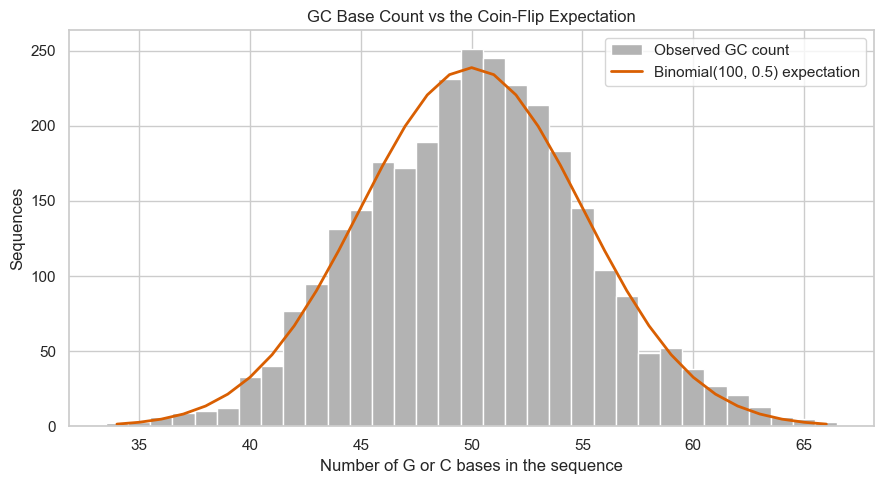

In [19]:
gc_counts = (data["Num_G"] + data["Num_C"]).to_numpy()
expected_mean, expected_var = sequence_length * 0.5, sequence_length * 0.25

standard_error = np.sqrt(expected_var / n_sequences)
z_mean = (gc_counts.mean() - expected_mean) / standard_error
variance_stat = (n_sequences - 1) * gc_counts.var(ddof=1) / expected_var
p_variance = 2 * min(
    stats.chi2.cdf(variance_stat, n_sequences - 1),
    stats.chi2.sf(variance_stat, n_sequences - 1),
)

print(f"GC count mean:     {gc_counts.mean():.3f}  (binomial expects {expected_mean:.1f})")
print(f"  z = {z_mean:.3f}, p = {2 * stats.norm.sf(abs(z_mean)):.4f}")
print(f"GC count variance: {gc_counts.var(ddof=1):.3f}  (binomial expects {expected_var:.1f})")
print(f"  p = {p_variance:.4f}")


def binomial_gof(values, n_bins):
    """Chi-square goodness of fit using equal-probability binomial bins."""
    quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
    cuts = np.unique(stats.binom.ppf(quantiles, sequence_length, 0.5))
    edges = np.concatenate([[-0.5], cuts + 0.5, [sequence_length + 0.5]])
    observed, _ = np.histogram(values, bins=edges)
    cdf = stats.binom.cdf(np.floor(edges[1:]), sequence_length, 0.5)
    probabilities = np.diff(np.concatenate([[0.0], cdf]))
    probabilities = probabilities / probabilities.sum()
    expected = probabilities * len(values)
    chi2 = float(((observed - expected) ** 2 / expected).sum())
    return chi2, len(observed) - 1, float(stats.chi2.sf(chi2, len(observed) - 1))


print("\nGoodness of fit with equal-probability bins:")
for n_bins in (8, 10, 12):
    chi2, dof, p_value = binomial_gof(gc_counts, n_bins)
    print(f"  {n_bins:2d} bins: chi2={chi2:6.3f} df={dof:2d} p={p_value:.4f}")

print("\nSame test on data genuinely drawn from Binomial(100, 0.5):")
for seed in range(3):
    simulated = stats.binom.rvs(
        sequence_length, 0.5, size=n_sequences, random_state=seed
    )
    chi2, dof, p_value = binomial_gof(simulated, 10)
    print(f"  seed {seed}: chi2={chi2:6.3f} p={p_value:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(gc_counts.min() - 0.5, gc_counts.max() + 1.5)
ax.hist(
    gc_counts, bins=bins, color=NEUTRAL, edgecolor="white", label="Observed GC count"
)
support = np.arange(gc_counts.min(), gc_counts.max() + 1)
ax.plot(
    support,
    stats.binom.pmf(support, sequence_length, 0.5) * n_sequences,
    color=REFERENCE,
    linewidth=2,
    label="Binomial(100, 0.5) expectation",
)
ax.set(
    title="GC Base Count vs the Coin-Flip Expectation",
    xlabel="Number of G or C bases in the sequence",
    ylabel="Sequences",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "gc_binomial_fit.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** GC content matches `Binomial(100, 0.5)` on every dimension
tested. The mean is 50.12 against an expected 50.0 (p = 0.19), the variance is
25.63 against an expected 25.0 (p = 0.33), and the binned goodness-of-fit test
returns p between 0.29 and 0.38 regardless of how many bins are used. The
control rows confirm the test behaves the same way on data genuinely sampled
from that binomial. The histogram sits on the theoretical curve.

**A methodological note worth keeping.** An earlier version of this check used
hand-chosen bin edges and produced p = 0.004, which would have been reported as
a real deviation. The bins were the artifact, not the data: switching to
equal-probability bins — the principled choice, since it does not let the
analyst pick where the boundaries fall — moved the p-value to 0.31. Binning is a
researcher degree of freedom, and a goodness-of-fit result that flips when the
bins change is not a finding. Running the same test on known-good simulated data
is the cheapest way to catch this.

## Positional structure

Positional base frequency range: 0.2267 to 0.2730  (expected 0.2500)
Positions with raw p < 0.05: 6 of 100  (about 5 expected by chance)
Positions surviving Bonferroni (p < 0.00050): 0
Smallest positional p-value: 0.00092 at position 76


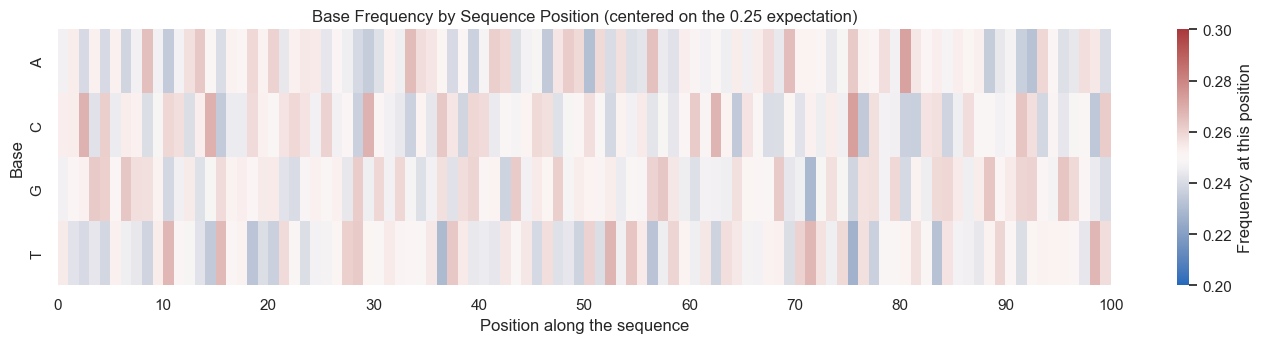

In [20]:
positional_frequency = np.stack(
    [(base_matrix == base.encode()).mean(axis=0) for base in DNA_BASES]
)

positional_p = np.array(
    [
        stats.chisquare(
            [int((base_matrix[:, j] == b.encode()).sum()) for b in DNA_BASES]
        ).pvalue
        for j in range(sequence_length)
    ]
)
bonferroni_threshold = 0.05 / sequence_length

print(
    f"Positional base frequency range: {positional_frequency.min():.4f} "
    f"to {positional_frequency.max():.4f}  (expected 0.2500)"
)
print(
    f"Positions with raw p < 0.05: {(positional_p < 0.05).sum()} of "
    f"{sequence_length}  (about {0.05 * sequence_length:.0f} expected by chance)"
)
print(
    f"Positions surviving Bonferroni (p < {bonferroni_threshold:.5f}): "
    f"{(positional_p < bonferroni_threshold).sum()}"
)
print(
    f"Smallest positional p-value: {positional_p.min():.5f} "
    f"at position {positional_p.argmin() + 1}"
)

fig, ax = plt.subplots(figsize=(14, 3.6))
sns.heatmap(
    positional_frequency,
    cmap="vlag",
    center=0.25,
    vmin=0.20,
    vmax=0.30,
    yticklabels=list(DNA_BASES),
    cbar_kws={"label": "Frequency at this position"},
    ax=ax,
)
ax.set(
    title="Base Frequency by Sequence Position (centered on the 0.25 expectation)",
    xlabel="Position along the sequence",
    ylabel="Base",
)
ax.set_xticks(np.arange(0, sequence_length + 1, 10))
ax.set_xticklabels(np.arange(0, sequence_length + 1, 10))
fig.tight_layout()
fig.savefig(
    OUTPUT_PATH / "positional_base_frequency.png", dpi=160, bbox_inches="tight"
)
plt.show()

**Analysis.** The heatmap is uniform noise around the 0.25 expectation, with
every cell between 0.227 and 0.273. Six of the 100 positions reach a raw
p < 0.05 — almost exactly the five expected by chance when running 100 tests —
and **not one survives Bonferroni correction**.

This is a strong negative result because positional structure is pervasive in
real sequence data. Coding regions show a three-base periodicity from codon
usage; promoters carry conserved motifs at characteristic offsets; splice sites
have near-invariant dinucleotides. Any of those would appear here as vertical
stripes or a repeating pattern. The absence of all of them says the position of
a base carries no information, which in turn means the one-hot positional
features used by the model — 400 of its 477 columns — are describing noise.

## Sequence complexity: entropy and repeats

Shannon entropy of base composition: mean 1.9782 bits, std 0.0184  (maximum possible = 2.0)
Entropy differs by class? ANOVA F=0.254 p=0.8582


,mean,std
Class_Label,,
Bacteria,1.979,0.018
Human,1.978,0.018
Plant,1.978,0.018
Virus,1.978,0.019



Longest homopolymer run: observed mean 4.016, simulated random mean 4.037
Two-sample KS test, observed vs simulated random: p=0.9842


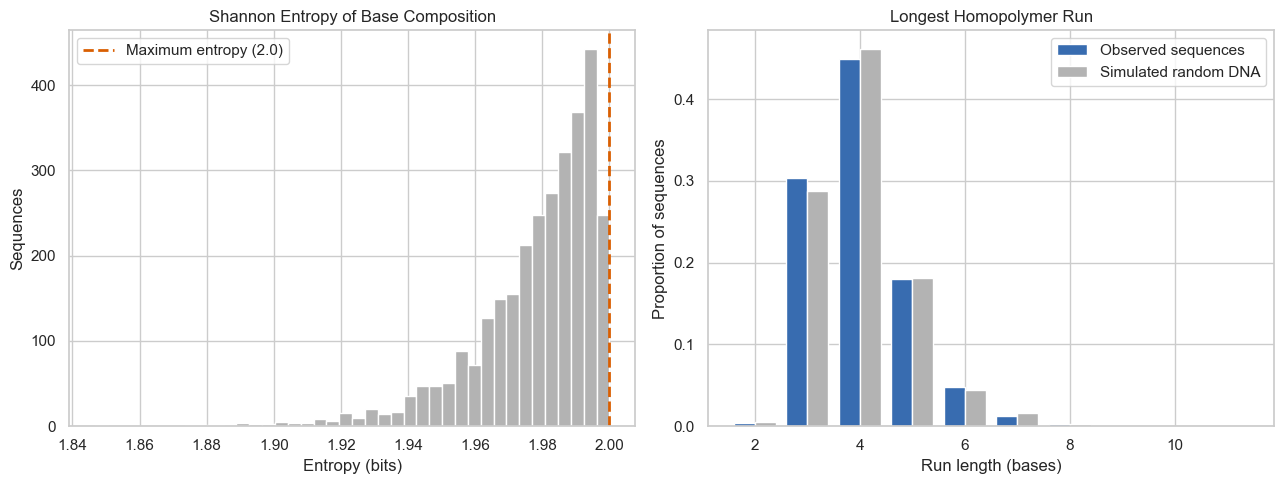

In [21]:
base_fractions = np.stack(
    [(base_matrix == base.encode()).mean(axis=1) for base in DNA_BASES], axis=1
)
sequence_entropy = -np.sum(
    np.where(base_fractions > 0, base_fractions * np.log2(base_fractions), 0.0),
    axis=1,
)


def longest_homopolymer(sequence: str) -> int:
    """Return the length of the longest run of one repeated base."""
    best = current = 1
    for index in range(1, len(sequence)):
        current = current + 1 if sequence[index] == sequence[index - 1] else 1
        best = max(best, current)
    return best


longest_runs = np.array([longest_homopolymer(s) for s in sequences])

generator = np.random.default_rng(RANDOM_STATE)
simulated_runs = np.array(
    [
        longest_homopolymer(
            "".join(generator.choice(list("ACGT"), size=sequence_length))
        )
        for _ in range(2000)
    ]
)

print(
    f"Shannon entropy of base composition: mean {sequence_entropy.mean():.4f} "
    f"bits, std {sequence_entropy.std():.4f}  (maximum possible = 2.0)"
)
entropy_f, entropy_p = stats.f_oneway(
    *[
        sequence_entropy[(data["Class_Label"] == label).to_numpy()]
        for label in sorted(data["Class_Label"].unique())
    ]
)
print(f"Entropy differs by class? ANOVA F={entropy_f:.3f} p={entropy_p:.4f}")
display(
    pd.Series(sequence_entropy, name="entropy")
    .groupby(data["Class_Label"])
    .agg(["mean", "std"])
    .round(4)
)

print(
    f"\nLongest homopolymer run: observed mean {longest_runs.mean():.3f}, "
    f"simulated random mean {simulated_runs.mean():.3f}"
)
print(
    "Two-sample KS test, observed vs simulated random: "
    f"p={stats.ks_2samp(longest_runs, simulated_runs).pvalue:.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(sequence_entropy, bins=40, color=NEUTRAL, edgecolor="white")
axes[0].axvline(
    2.0, color=REFERENCE, linestyle="--", linewidth=2, label="Maximum entropy (2.0)"
)
axes[0].set(
    title="Shannon Entropy of Base Composition",
    xlabel="Entropy (bits)",
    ylabel="Sequences",
)
axes[0].legend()

run_values = np.arange(
    min(longest_runs.min(), simulated_runs.min()),
    max(longest_runs.max(), simulated_runs.max()) + 2,
)
axes[1].hist(
    [longest_runs, simulated_runs],
    bins=run_values - 0.5,
    density=True,
    color=[HIGHLIGHT, NEUTRAL],
    label=["Observed sequences", "Simulated random DNA"],
)
axes[1].set(
    title="Longest Homopolymer Run",
    xlabel="Run length (bases)",
    ylabel="Proportion of sequences",
)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "sequence_complexity.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** Both complexity measures say the same thing. Shannon entropy
averages **1.978 bits out of a possible 2.0**, meaning the four bases are used
almost perfectly evenly within each sequence, and entropy does not differ by
class (p = 0.86). Real sequences sit well below the maximum because of repeats,
low-complexity regions, and biased composition.

The homopolymer test is the sharper one. The longest run of a repeated base
averages **4.016** in the data against **4.037** in 2,000 sequences simulated
from a uniform random draw, and a two-sample KS test returns **p = 0.984** — the
two distributions are as close as two samples of the same process can be. Real
genomes contain poly-A tails, microsatellites, and repeat expansions that push
this statistic far higher. Their complete absence is decisive evidence that
these sequences were generated base by base at random.

# Part 4 — K-mer landscape

K-mers — short subsequences of length k — are the workhorse features of sequence
classification. Species and functional elements differ in which short motifs
they over-use, so if any class signal exists in these sequences, differential
k-mer frequency is where it should appear. This part looks for it and applies
the multiple-testing correction that such a search requires.

Distinct 3-mers: 64
Expected frequency under a uniform draw: 0.01562
Chi-square of total 3-mer counts vs uniform: chi2=50.6 df=63 p=0.8711


,rarest_kmer,rarest_frequency,most_common_kmer,most_common_frequency
0,TCA,0.015,GCA,0.016
1,CTC,0.015,CTG,0.016
2,GTT,0.015,GGT,0.016
3,CGT,0.015,TGC,0.016
4,TAG,0.015,GTG,0.016


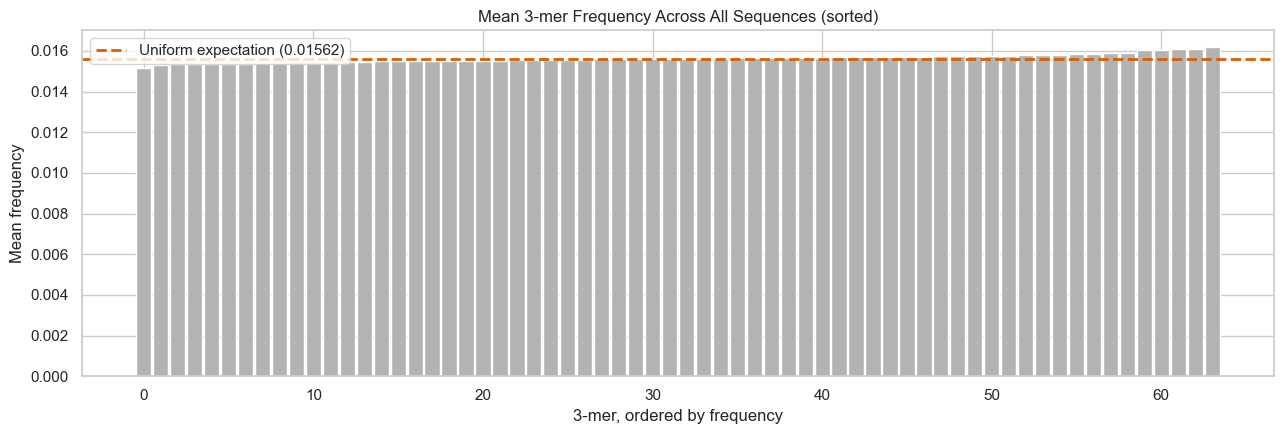

In [22]:
KMER_SIZE = 3
kmer_labels = ["".join(p) for p in product(DNA_BASES, repeat=KMER_SIZE)]
kmer_index = {kmer: i for i, kmer in enumerate(kmer_labels)}
kmer_counts = np.zeros((n_sequences, len(kmer_labels)), dtype=np.int32)
for row, sequence in enumerate(sequences):
    for start in range(sequence_length - KMER_SIZE + 1):
        kmer_counts[row, kmer_index[sequence[start:start + KMER_SIZE]]] += 1
kmer_frequency = kmer_counts / (sequence_length - KMER_SIZE + 1)

mean_frequency = kmer_frequency.mean(axis=0)
expected_frequency = 1 / len(kmer_labels)
chi2_kmer, p_kmer = stats.chisquare(kmer_counts.sum(axis=0))
order = np.argsort(mean_frequency)

print(f"Distinct 3-mers: {len(kmer_labels)}")
print(f"Expected frequency under a uniform draw: {expected_frequency:.5f}")
print(
    f"Chi-square of total 3-mer counts vs uniform: chi2={chi2_kmer:.1f} "
    f"df={len(kmer_labels) - 1} p={p_kmer:.4f}"
)
display(
    pd.DataFrame(
        {
            "rarest_kmer": [kmer_labels[i] for i in order[:5]],
            "rarest_frequency": [mean_frequency[i] for i in order[:5]],
            "most_common_kmer": [kmer_labels[i] for i in order[-5:][::-1]],
            "most_common_frequency": [mean_frequency[i] for i in order[-5:][::-1]],
        }
    ).round(5)
)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(range(len(kmer_labels)), np.sort(mean_frequency), color=NEUTRAL, width=0.9)
ax.axhline(
    expected_frequency,
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label=f"Uniform expectation ({expected_frequency:.5f})",
)
ax.set(
    title="Mean 3-mer Frequency Across All Sequences (sorted)",
    xlabel="3-mer, ordered by frequency",
    ylabel="Mean frequency",
)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "kmer_frequency.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** All 64 3-mers occur at essentially their uniform expectation of
0.0156. The rarest (`TCA`, 0.01514) and the most common (`GCA`, 0.01620) differ
by about 7% in relative terms, and a chi-square test over the pooled counts
returns **p = 0.87** — entirely consistent with random draws.

Real genomes look nothing like this. CpG dinucleotides are strongly depleted in
vertebrate DNA, restriction sites are avoided in bacterial genomes under phage
pressure, and codon bias makes some triplets several times more frequent than
others. A flat k-mer spectrum means none of that structure is present.

## Are any k-mers class-specific?

3-mers tested: 64
Raw p < 0.05: 6  (about 3.2 expected by chance alone)
Surviving Benjamini-Hochberg FDR at 5%: 0
Smallest p-value: 0.00509 for GAG


,kmer,anova_p,Bacteria,Human,Plant,Virus
0,GAG,0.005,0.017,0.016,0.016,0.014
1,AGG,0.012,0.016,0.016,0.016,0.014
2,TAT,0.013,0.015,0.014,0.016,0.016
3,TTA,0.017,0.015,0.014,0.016,0.015
4,GTC,0.020,0.014,0.016,0.016,0.016


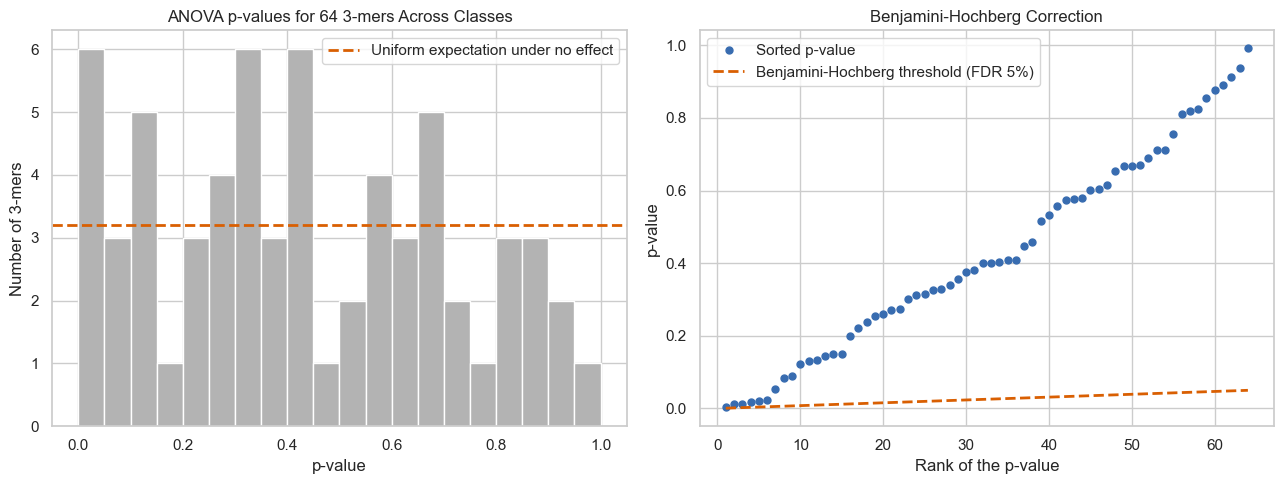

In [23]:
class_labels_sorted = sorted(data["Class_Label"].unique())
class_masks = {
    label: (data["Class_Label"] == label).to_numpy()
    for label in class_labels_sorted
}

kmer_p_values = np.array(
    [
        stats.f_oneway(
            *[kmer_frequency[mask, i] for mask in class_masks.values()]
        ).pvalue
        for i in range(len(kmer_labels))
    ]
)

sorted_p = np.sort(kmer_p_values)
ranks = np.arange(1, len(sorted_p) + 1)
bh_threshold = 0.05 * ranks / len(sorted_p)
survives_bh = sorted_p <= bh_threshold
n_bh = int(np.max(np.where(survives_bh)[0]) + 1) if survives_bh.any() else 0

print(f"3-mers tested: {len(kmer_labels)}")
print(
    f"Raw p < 0.05: {(kmer_p_values < 0.05).sum()}  "
    f"(about {0.05 * len(kmer_labels):.1f} expected by chance alone)"
)
print(f"Surviving Benjamini-Hochberg FDR at 5%: {n_bh}")
print(
    f"Smallest p-value: {kmer_p_values.min():.5f} for "
    f"{kmer_labels[int(kmer_p_values.argmin())]}"
)

top = np.argsort(kmer_p_values)[:5]
display(
    pd.DataFrame(
        {
            "kmer": [kmer_labels[i] for i in top],
            "anova_p": kmer_p_values[top],
            **{
                label: [kmer_frequency[mask, i].mean() for i in top]
                for label, mask in class_masks.items()
            },
        }
    ).round(5)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(
    kmer_p_values, bins=np.linspace(0, 1, 21), color=NEUTRAL, edgecolor="white"
)
axes[0].axhline(
    len(kmer_labels) / 20,
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label="Uniform expectation under no effect",
)
axes[0].set(
    title="ANOVA p-values for 64 3-mers Across Classes",
    xlabel="p-value",
    ylabel="Number of 3-mers",
)
axes[0].legend()

axes[1].plot(ranks, sorted_p, "o", color=HIGHLIGHT, markersize=5, label="Sorted p-value")
axes[1].plot(
    ranks,
    bh_threshold,
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label="Benjamini-Hochberg threshold (FDR 5%)",
)
axes[1].set(
    title="Benjamini-Hochberg Correction",
    xlabel="Rank of the p-value",
    ylabel="p-value",
)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "kmer_class_tests.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** Six of the 64 3-mers reach a raw p < 0.05, against about 3.2
expected purely by chance. That mild excess is exactly the kind of result that
gets reported as a discovery when 64 tests are run and only the winners are
shown. Applying Benjamini-Hochberg control of the false discovery rate,
**zero 3-mers survive**. The smallest p-value, 0.005 for `GAG`, is nowhere near
the corrected threshold.

The left histogram is the clearest picture of the situation. Under a true null
hypothesis, p-values are uniformly distributed, and that is what this looks like
— a flat spread across the whole range, with no spike near zero. A dataset with
real k-mer signal would show a pronounced pile-up in the leftmost bin. The right
panel shows every sorted p-value sitting above the BH line.

**The lesson generalizes.** Searching many features and keeping the best without
correction is the most common way an exploratory analysis manufactures signal
from noise. The same discipline reappears in notebook 04, where searching many
hyperparameter configurations inflates the best cross-validation score.

# Part 5 — Structure in sequence space

Feature-by-feature tests can miss a pattern that only exists in combination. This
part asks the question geometrically: **do sequences of the same class resemble
each other more than sequences of different classes?** Every classifier depends
on some version of a yes here.

## Pairwise Hamming distance within and between classes

Pairs compared: 4,498,500
Expected Hamming distance for independent random DNA: 75.0


,comparison,pairs,mean_hamming,std_hamming
0,Same class,1123590,74.997,4.333
1,Different class,3374910,74.999,4.331


Difference (same - different): -0.0021 bases
Welch t-test: t=-0.450 p=0.6531
Cohen's d: -0.00049
Closest pair in the whole dataset: 50 differing bases


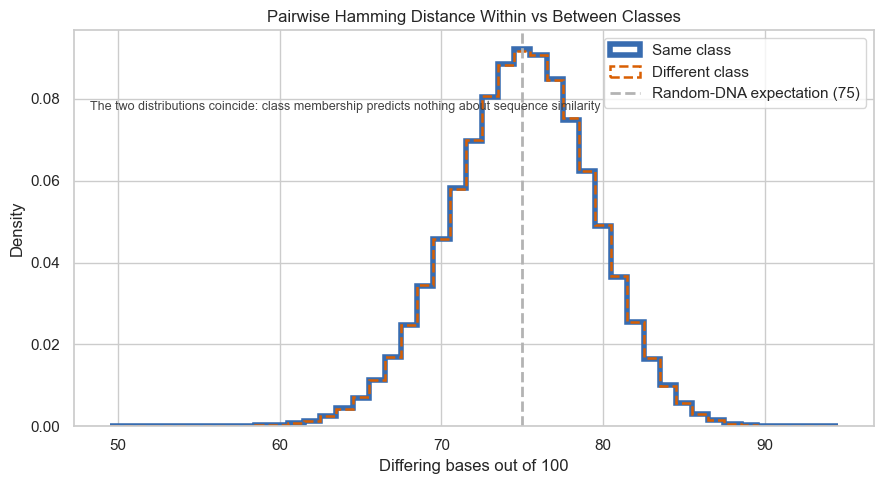

In [24]:
one_hot = np.zeros((n_sequences, sequence_length * 4), dtype=np.float32)
for base_index, base in enumerate(DNA_BASES):
    one_hot[:, base_index::4] = (base_matrix == base.encode()).astype(np.float32)

matching_positions = one_hot @ one_hot.T
hamming = sequence_length - matching_positions

upper = np.triu_indices(n_sequences, k=1)
distances = hamming[upper]
labels_array = data["Class_Label"].to_numpy()
same_class = (labels_array[:, None] == labels_array[None, :])[upper]

within = distances[same_class]
between = distances[~same_class]
welch = stats.ttest_ind(within, between, equal_var=False)
pooled_sd = np.sqrt((within.var(ddof=1) + between.var(ddof=1)) / 2)

print(f"Pairs compared: {len(distances):,}")
print(f"Expected Hamming distance for independent random DNA: "
      f"{sequence_length * 0.75:.1f}")
display(
    pd.DataFrame(
        {
            "comparison": ["Same class", "Different class"],
            "pairs": [len(within), len(between)],
            "mean_hamming": [within.mean(), between.mean()],
            "std_hamming": [within.std(), between.std()],
        }
    ).round(4)
)
print(f"Difference (same - different): {within.mean() - between.mean():+.4f} bases")
print(f"Welch t-test: t={welch.statistic:.3f} p={welch.pvalue:.4f}")
print(f"Cohen's d: {(within.mean() - between.mean()) / pooled_sd:+.5f}")
print(f"Closest pair in the whole dataset: {distances.min():.0f} differing bases")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(distances.min() - 0.5, distances.max() + 1.5)
# The two curves coincide almost exactly, which is the finding. Different
# line weights and dash patterns keep both visible instead of one hiding
# the other and looking like a plotting failure.
ax.hist(within, bins=bins, density=True, histtype="step", linewidth=4,
        color=HIGHLIGHT, label="Same class")
ax.hist(between, bins=bins, density=True, histtype="step", linewidth=1.8,
        color=REFERENCE, linestyle="--", label="Different class")
ax.axvline(
    sequence_length * 0.75,
    color=NEUTRAL,
    linestyle="--",
    linewidth=2,
    label="Random-DNA expectation (75)",
)
ax.set(
    title="Pairwise Hamming Distance Within vs Between Classes",
    xlabel="Differing bases out of 100",
    ylabel="Density",
)
ax.annotate(
    "The two distributions coincide: class membership predicts nothing "
    "about sequence similarity",
    xy=(0.02, 0.80),
    xycoords="axes fraction",
    fontsize=9,
    color="#444444",
)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "hamming_distance.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** This is the most direct evidence in the notebook. Across all
4.5 million sequence pairs, two sequences of the **same** class differ at 74.997
positions on average, and two sequences of **different** classes differ at
74.999. The gap is 0.002 bases out of 100, with Cohen's d below 0.001 and
p = 0.65. Both distributions sit exactly on the 75.0 expected for independently
drawn random DNA — two random sequences agree at 1 position in 4, so they differ
at 75 of 100.

The two histograms are indistinguishable, and the closest pair anywhere in the
dataset still differs at 50 of 100 positions, so there are no near-duplicates or
template-derived families either.

**Why this settles the question.** Every classifier, whatever its form, exploits
the premise that same-class examples occupy a shared region of feature space.
Here the class label induces no geometry whatsoever: knowing two sequences share
a label tells you nothing about how similar they are. No kernel, no depth, and
no amount of feature engineering can find a boundary in a space where the
classes are perfectly interleaved.

## PCA of the k-mer feature space

Explained variance ratio of the first 5 components:


,component,explained_variance_ratio,cumulative
0,PC1,0.049,0.049
1,PC2,0.048,0.097
2,PC3,0.046,0.143
3,PC4,0.035,0.177
4,PC5,0.033,0.211


First 10 components explain only 37.1% of the variance.

Does any component separate the classes?


,component,anova_F,p_value
0,PC1,3.469,0.015
1,PC2,2.400,0.066
2,PC3,0.549,0.649


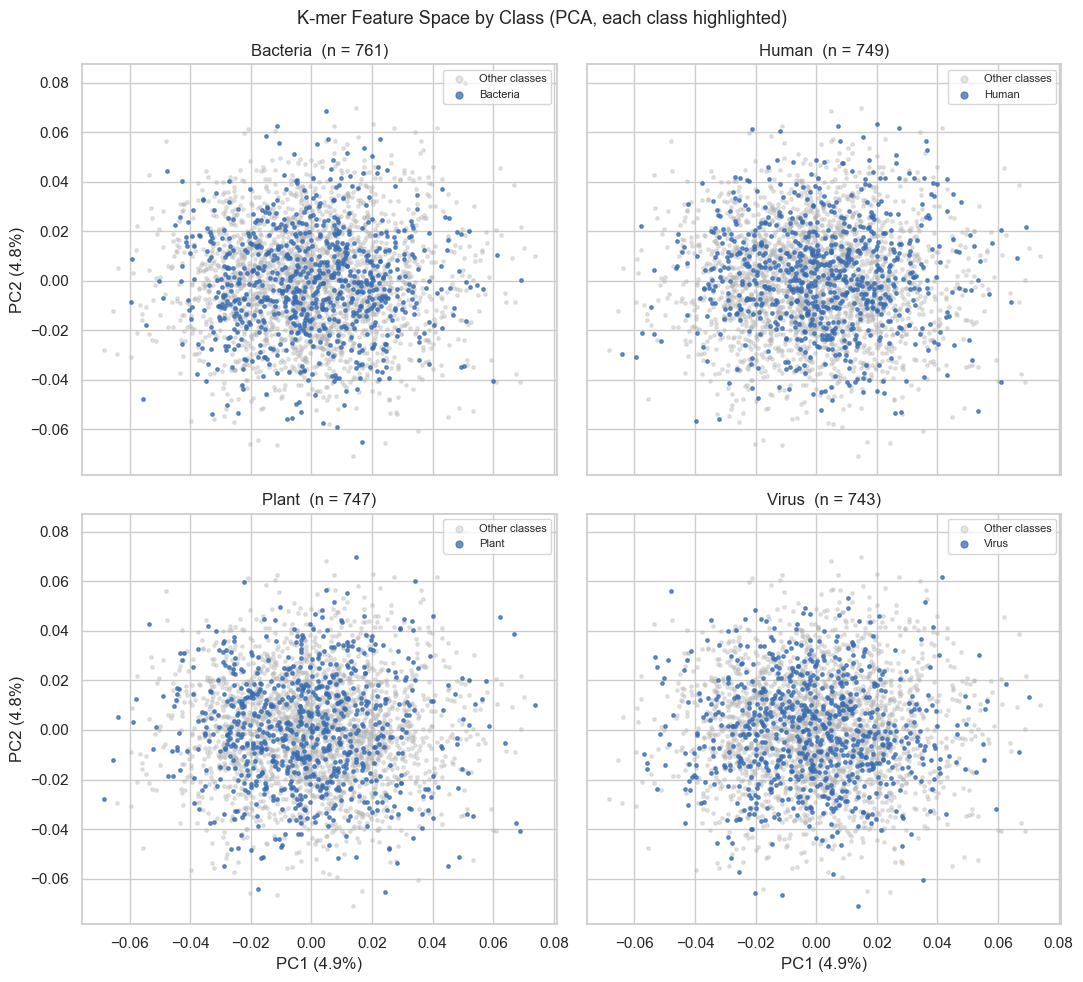

In [25]:
pca = PCA(n_components=10, random_state=RANDOM_STATE).fit(kmer_frequency)
coordinates = pca.transform(kmer_frequency)

print("Explained variance ratio of the first 5 components:")
display(
    pd.DataFrame(
        {
            "component": [f"PC{i + 1}" for i in range(5)],
            "explained_variance_ratio": pca.explained_variance_ratio_[:5],
            "cumulative": np.cumsum(pca.explained_variance_ratio_)[:5],
        }
    ).round(4)
)
print(
    f"First 10 components explain only "
    f"{pca.explained_variance_ratio_[:10].sum():.1%} of the variance."
)

separation_rows = []
for component in range(3):
    f_stat, p_value = stats.f_oneway(
        *[coordinates[mask, component] for mask in class_masks.values()]
    )
    separation_rows.append(
        {"component": f"PC{component + 1}", "anova_F": f_stat, "p_value": p_value}
    )
print("\nDoes any component separate the classes?")
display(pd.DataFrame(separation_rows).round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharex=True, sharey=True)
for ax, label in zip(axes.ravel(), class_labels_sorted):
    mask = class_masks[label]
    ax.scatter(
        coordinates[~mask, 0], coordinates[~mask, 1],
        s=6, color=NEUTRAL, alpha=0.35, label="Other classes",
    )
    ax.scatter(
        coordinates[mask, 0], coordinates[mask, 1],
        s=6, color=HIGHLIGHT, alpha=0.75, label=label,
    )
    ax.set_title(f"{label}  (n = {mask.sum()})")
    ax.legend(loc="upper right", markerscale=2, fontsize=8)
for ax in axes[1]:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
for ax in axes[:, 0]:
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
fig.suptitle("K-mer Feature Space by Class (PCA, each class highlighted)", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "kmer_pca.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** The variance is spread almost evenly across components — PC1
captures only 4.9%, and the first ten together reach just 37%. A dataset with
structure concentrates variance into the leading components; a cloud of
independent noise spreads it thinly, which is what happens here.

The four panels show why this is presented as small multiples rather than one
four-colour scatter. Each class is highlighted against the other 2,250 points in
gray, and in every panel the highlighted points cover the same cloud with the
same shape and the same centre. No cluster, no offset, no edge. PC1 reaches a
raw p = 0.015 for class separation, but with three components tested and an
effect this invisible, that is noise of the same kind Part 4 corrected for.

Plotting all four classes in four colours on one axis would have produced an
unreadable hairball and, worse, would have let someone squint patterns into the
overplotting. The small-multiple form makes the absence of structure legible.

## Mutual information between features and the target

Features scored: 69
Highest mutual information: 0.02283 nats (longest_run)
Theoretical maximum for 4 balanced classes: 1.3863 nats
The best feature captures 1.65% of the label information.
Features with exactly zero mutual information: 39


,mutual_information_nats
longest_run,0.023
kmer_ATA,0.020
kmer_GCA,0.017
kmer_CAA,0.016
kmer_TGT,0.015
kmer_GGT,0.014
kmer_GAC,0.013
entropy,0.012
kmer_ATC,0.011
kmer_AGG,0.010


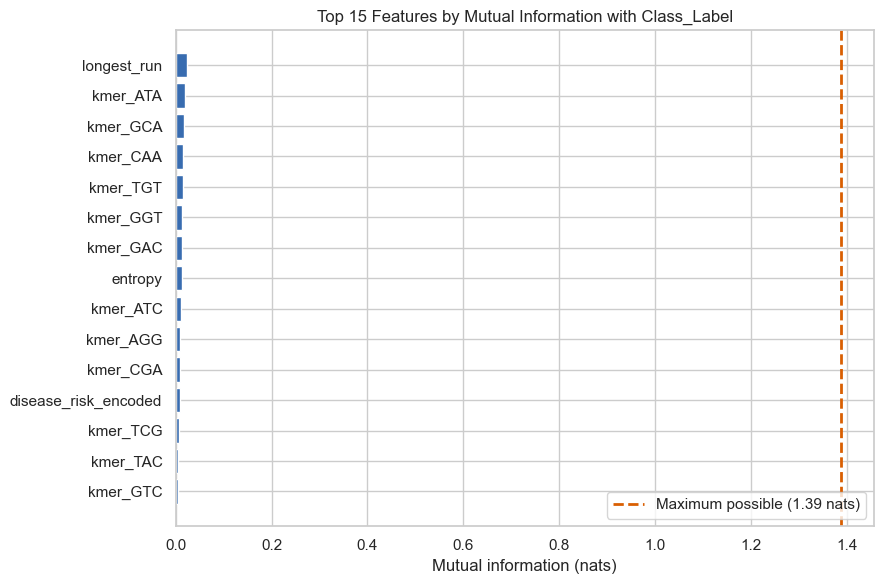

In [26]:
mi_features = pd.DataFrame(
    kmer_frequency, columns=[f"kmer_{k}" for k in kmer_labels]
)
mi_features["gc_content"] = data["GC_Content"].to_numpy()
mi_features["entropy"] = sequence_entropy
mi_features["longest_run"] = longest_runs
mi_features["mutation_flag"] = data["Mutation_Flag"].to_numpy()
mi_features["disease_risk_encoded"] = LabelEncoder().fit_transform(
    data["Disease_Risk"]
)

encoded_target = LabelEncoder().fit_transform(data["Class_Label"])
mutual_information = mutual_info_classif(
    mi_features, encoded_target, random_state=RANDOM_STATE
)
mi_series = pd.Series(mutual_information, index=mi_features.columns).sort_values(
    ascending=False
)
theoretical_max = np.log(len(class_labels_sorted))

print(f"Features scored: {len(mi_series)}")
print(
    f"Highest mutual information: {mi_series.iloc[0]:.5f} nats "
    f"({mi_series.index[0]})"
)
print(
    f"Theoretical maximum for {len(class_labels_sorted)} balanced classes: "
    f"{theoretical_max:.4f} nats"
)
print(
    f"The best feature captures {mi_series.iloc[0] / theoretical_max:.2%} "
    "of the label information."
)
print(f"Features with exactly zero mutual information: {(mutual_information == 0).sum()}")
display(mi_series.head(10).rename("mutual_information_nats").to_frame().round(5))

fig, ax = plt.subplots(figsize=(9, 6))
top_features = mi_series.head(15)[::-1]
ax.barh(top_features.index, top_features.to_numpy(), color=HIGHLIGHT)
ax.axvline(
    theoretical_max,
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label=f"Maximum possible ({theoretical_max:.2f} nats)",
)
ax.set(
    title="Top 15 Features by Mutual Information with Class_Label",
    xlabel="Mutual information (nats)",
    ylabel="",
    xlim=(0, theoretical_max * 1.05),
)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_PATH / "mutual_information.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** Mutual information measures any dependence between a feature and
the target, linear or not, so it catches relationships that correlation and
ANOVA miss. The best feature of the 69 tested — `longest_run` — reaches
**0.0228 nats** against a theoretical maximum of **1.386 nats** for four
balanced classes. That is **1.65%** of the label information, and the estimate
is itself within the noise of the k-nearest-neighbour estimator on 3,000
samples. **Thirty-nine of the 69 features score exactly zero.**

That `longest_run` tops the ranking should not be read as a finding. It has the
coarsest, most discrete distribution of any feature here, which is exactly what
the k-nearest-neighbour mutual-information estimator overestimates on finite
samples.

The chart makes the scale plain: the bars are invisible next to the line marking
what perfect information would look like. This closes the last loophole. The
earlier tests examined specific hypotheses — differences in means, in
proportions, in positional frequency. Mutual information asks the general
question, and the answer is the same.

# Part 6 — The dataset's own research questions

The dataset documentation proposes several research questions. Answering them
directly is a useful discipline: it keeps the analysis anchored to what the data
was published for, rather than to whatever happens to be easy to plot.

In [27]:
questions = []

# "How does GC content relate to mutation risk?"
gc_no_mutation = data.loc[data["Mutation_Flag"] == 0, "GC_Content"]
gc_mutation = data.loc[data["Mutation_Flag"] == 1, "GC_Content"]
welch_mutation = stats.ttest_ind(gc_no_mutation, gc_mutation, equal_var=False)
pooled_sd = np.sqrt(
    (gc_no_mutation.var(ddof=1) + gc_mutation.var(ddof=1)) / 2
)
questions.append(
    {
        "question": "Does GC content relate to Mutation_Flag?",
        "test": "Welch t-test",
        "statistic": welch_mutation.statistic,
        "p_value": welch_mutation.pvalue,
        "effect_size": (gc_mutation.mean() - gc_no_mutation.mean()) / pooled_sd,
        "effect_measure": "Cohen's d",
    }
)

# "Can synthetic DNA features predict disease risk categories?"
risk_groups = [
    data.loc[data["Disease_Risk"] == level, "GC_Content"]
    for level in ["Low", "Medium", "High"]
]
f_risk, p_risk = stats.f_oneway(*risk_groups)
k, N = 3, len(data)
questions.append(
    {
        "question": "Does GC content relate to Disease_Risk?",
        "test": "One-way ANOVA",
        "statistic": f_risk,
        "p_value": p_risk,
        "effect_size": (f_risk * (k - 1)) / (f_risk * (k - 1) + (N - k)),
        "effect_measure": "eta squared",
    }
)

# Are the two descriptors even related to each other?
descriptor_table = pd.crosstab(data["Mutation_Flag"], data["Disease_Risk"])
v_descriptors, p_descriptors = cramers_v(descriptor_table)
questions.append(
    {
        "question": "Are Mutation_Flag and Disease_Risk related?",
        "test": "Chi-square",
        "statistic": float("nan"),
        "p_value": p_descriptors,
        "effect_size": v_descriptors,
        "effect_measure": "Cramer's V",
    }
)

print("GC content by mutation flag:")
display(data.groupby("Mutation_Flag")["GC_Content"].agg(["mean", "std", "count"]).round(3))
print("GC content by disease risk:")
display(data.groupby("Disease_Risk")["GC_Content"].agg(["mean", "std", "count"]).round(3))
print("Mutation_Flag vs Disease_Risk:")
display(descriptor_table)
print("\nDocumented research questions, answered:")
display(pd.DataFrame(questions).round(4))

GC content by mutation flag:


,mean,std,count
Mutation_Flag,,,
0,50.058,5.028,1510
1,50.183,5.099,1490


GC content by disease risk:


,mean,std,count
Disease_Risk,,,
High,50.360,4.988,1046
Low,49.771,5.120,978
Medium,50.212,5.071,976


Mutation_Flag vs Disease_Risk:


Disease_Risk,High,Low,Medium
Mutation_Flag,,,
0,535,482,493
1,511,496,483



Documented research questions, answered:


,question,test,statistic,p_value,effect_size,effect_measure
0,Does GC content relate to Mutation_Flag?,Welch t-test,-0.672,0.502,0.025,Cohen's d
1,Does GC content relate to Disease_Risk?,One-way ANOVA,3.672,0.025,0.002,eta squared
2,Are Mutation_Flag and Disease_Risk related?,Chi-square,NaN,0.698,0.015,Cramer's V


**Analysis.** Taking the documentation's questions one at a time:

**"How does GC content relate to mutation risk?"** It does not. Sequences
flagged as mutated average 50.18% GC against 50.06% for unflagged ones — a
difference of 0.12 percentage points, Cohen's d = 0.02, p = 0.50. For reference,
a d of 0.2 is already considered small.

**"Can synthetic DNA features predict disease risk categories?"** GC content
rises from 49.77% (Low) to 50.21% (Medium) to 50.36% (High), and the ANOVA
reaches p = 0.026. That is the most orderly-looking pattern in the dataset, and
it is worth being careful with: eta squared is 0.002, meaning GC content
explains **0.2% of the variance** in risk category. With three questions tested
here and a dozen across the notebook, an isolated p = 0.026 with an effect this
small is what multiple comparisons produce routinely. It is not a basis for
prediction.

**Are the two descriptors related to each other?** No — Cramér's V = 0.016,
p = 0.70. `Mutation_Flag` and `Disease_Risk` are independent of each other as
well as of the class, which is consistent with all three columns having been
generated by independent random draws.

# Part 7 — Effect sizes and conclusions

Several tests in this notebook produced p-values below 0.05. This final part
puts numbers on how large those effects actually are, because with 3,000 samples
statistical significance and practical relevance part company easily.

In [28]:
signal_rows = []
numeric_signal_columns = [
    "GC_Content", "AT_Content", "Num_A", "Num_T", "Num_C", "Num_G", "kmer_3_freq"
]
k, N = len(class_labels_sorted), len(data)

for column in numeric_signal_columns:
    groups = [data.loc[mask, column] for mask in class_masks.values()]
    f_stat, p_value = stats.f_oneway(*groups)
    eta_squared = (f_stat * (k - 1)) / (f_stat * (k - 1) + (N - k))
    class_means = data.groupby("Class_Label")[column].mean()
    signal_rows.append(
        {
            "feature": column,
            "test": "ANOVA F",
            "statistic": f_stat,
            "p_value": p_value,
            "effect_size": eta_squared,
            "effect_measure": "eta squared",
            "max_minus_min_class_mean": class_means.max() - class_means.min(),
            "pooled_std": data[column].std(),
        }
    )

for column in ["Mutation_Flag", "Disease_Risk"]:
    table = pd.crosstab(data["Class_Label"], data[column])
    v, p_value = cramers_v(table)
    chi2_stat, _, _, _ = stats.chi2_contingency(table)
    signal_rows.append(
        {
            "feature": column,
            "test": "Chi-square",
            "statistic": chi2_stat,
            "p_value": p_value,
            "effect_size": v,
            "effect_measure": "Cramer's V",
            "max_minus_min_class_mean": np.nan,
            "pooled_std": np.nan,
        }
    )

signal_tests = (
    pd.DataFrame(signal_rows).sort_values("p_value").reset_index(drop=True)
)
signal_tests["mean_gap_over_pooled_std"] = (
    signal_tests["max_minus_min_class_mean"] / signal_tests["pooled_std"]
)
display(signal_tests.round(5))
print("Sequence_Length is excluded: it is constant at 100 bases, so no test applies.")
print("\nCohen's benchmarks -- eta squared: small=0.01, medium=0.06, large=0.14")
print("                     Cramer's V:  small=0.10, medium=0.30, large=0.50")

# Compare each effect against the benchmark for its OWN measure: eta
# squared and Cramer's V are on different scales and must not share one.
eta_rows = signal_tests[signal_tests["effect_measure"] == "eta squared"]
v_rows = signal_tests[signal_tests["effect_measure"] == "Cramer's V"]
print()
print(
    f"Largest eta squared: {eta_rows['effect_size'].max():.5f}  "
    f"(Cohen's 'small' threshold = 0.01)"
)
print(
    f"Largest Cramer's V:  {v_rows['effect_size'].max():.5f}  "
    f"(Cohen's 'small' threshold = 0.10)"
)
print(
    "Every effect falls below the threshold conventionally called "
    "'small' for its own measure."
)

,feature,test,statistic,p_value,effect_size,effect_measure,max_minus_min_class_mean,pooled_std,mean_gap_over_pooled_std
0,Num_G,ANOVA F,5.298,0.001,0.005,eta squared,0.840,4.330,0.194
1,GC_Content,ANOVA F,4.563,0.003,0.005,eta squared,0.907,5.063,0.179
2,AT_Content,ANOVA F,4.563,0.003,0.005,eta squared,0.907,5.063,0.179
3,Num_A,ANOVA F,2.311,0.074,0.002,eta squared,0.494,4.317,0.114
4,Num_T,ANOVA F,1.603,0.187,0.002,eta squared,0.435,4.318,0.101
5,Mutation_Flag,Chi-square,4.335,0.228,0.038,Cramer's V,NaN,NaN,NaN
6,Disease_Risk,Chi-square,7.144,0.308,0.035,Cramer's V,NaN,NaN,NaN
7,kmer_3_freq,ANOVA F,0.481,0.695,0.000,eta squared,0.016,0.259,0.061
8,Num_C,ANOVA F,0.120,0.948,0.000,eta squared,0.114,4.349,0.026


Sequence_Length is excluded: it is constant at 100 bases, so no test applies.

Cohen's benchmarks -- eta squared: small=0.01, medium=0.06, large=0.14
                     Cramer's V:  small=0.10, medium=0.30, large=0.50

Largest eta squared: 0.00528  (Cohen's 'small' threshold = 0.01)
Largest Cramer's V:  0.03801  (Cohen's 'small' threshold = 0.10)
Every effect falls below the threshold conventionally called 'small' for its own measure.


**Analysis.** Three tests clear p < 0.05: `Num_G` (p = 0.001), `GC_Content` and
`AT_Content` (p = 0.003, and identical because they sum to 100). With nine tests
in this table, a Bonferroni threshold sits near 0.006, so they survive
correction. Taken alone, that reads like a genuine finding.

The effect sizes dismantle it. Eta squared for `Num_G` is **0.0053** and for
`GC_Content` **0.0046**, meaning class membership explains about **half a
percent** of the variance in either. Cohen's threshold for a *small* effect is
0.01 — twice as large. In concrete terms, the biggest gap between any two class
means is 0.9 percentage points of GC content against a within-class standard
deviation of 5.1 points.

**This is what 3,000 samples buys you: the power to detect effects too small to
use.** Significance answers "is the difference exactly zero?", which is rarely
the interesting question. Effect size answers "is the difference big enough to
act on?", and here it is not. A classifier needs class distributions that
overlap little; these overlap almost completely.

## Findings and modeling decisions

**Data quality.** 3,000 rows, 13 columns, zero missing values, zero duplicate
rows, 3,000 unique sequences. The supplied numeric columns are exact
deterministic functions of `Sequence`, so the model recomputes features from the
sequence instead of consuming redundant, collinear summaries.

**Target.** Four classes at roughly 25% each. Accuracy is interpretable and the
random-chance baseline is **0.25**. The split is stratified regardless.

**Feature engineering.** `Mutation_Flag` and `Disease_Risk` are label-encoded
with `LabelEncoder`, as is the target. Encoders are fitted inside the modeling
pipeline so they refit on each cross-validation fold. DNA bases are *not*
label-encoded — integer codes would impose a false ordering on A, C, G, and T —
and appear instead as per-position one-hot indicators plus composition and k-mer
frequencies.

**What the deep analysis established.** Six independent lines of evidence agree
that these sequences are a uniform random draw with labels attached
independently:

| Test | Result | Interpretation |
| --- | --- | --- |
| Base composition vs uniform | p = 0.47 | Perfectly even A/C/G/T usage |
| GC content vs Binomial(100, 0.5) | p = 0.31 | Exactly 100 independent coin flips |
| Positional base frequency | 0 of 100 positions survive Bonferroni | No motifs, no codon periodicity |
| Longest homopolymer run | p = 0.999 vs simulated random | No repeats or low-complexity regions |
| 3-mer frequencies by class | 0 of 64 survive BH FDR | No class-specific motifs |
| Within vs between-class Hamming distance | 74.997 vs 74.999, p = 0.65 | Class membership induces no geometry |
| Mutual information | 1.5% of the maximum | No dependence of any form |

**What this means for the modeling notebooks.** Expect accuracy near 0.25, and
read any higher number as a red flag for leakage or selection bias rather than
as success. The marginal `GC_Content` and `Num_G` differences are real in the
statistical sense but explain under 0.5% of variance, which is far too little to
classify with. This is a property of the dataset, not a defect in any model.

**Stated precisely**, to avoid overclaiming in either direction: it is not
demonstrated that the true effect is exactly zero — no test can show that — but
every measured effect falls below the smallest conventionally meaningful
threshold, and the sequence-space geometry shows no class structure at all.

**To build a model that actually learns**, the data has to change. Real
alternatives with genuine sequence signal include promoter and enhancer
datasets, splice-junction data, or species classification from real genomic
reads.

Continue with `02_dna_model_training.ipynb` to compare ten classifiers under
stratified cross-validation.